# Bayesian Fitting with BUMPS

This notebook demonstrates the full high-level Bayesian MCMC API in
EasyReflectometry.

It covers:

- Building a reflectometry model with realistic bounds (critical for MCMC).
- Classical optimisation first (good starting point for Bayesian sampling).
- High-level DREAM MCMC sampling via
  ``MultiFitter.mcmc_sample()`` and ``PosteriorResults``.
- Checking convergence with the Gelman-Rubin R-hat diagnostic, then
  **extending an under-converged chain** with ``fitter.sampler.extend()`` and
  comparing the posterior before and after.
- Posterior inspection: summary table, marginal distributions, corner plot,
  trace plot, credible intervals.
- Posterior-predictive checks: reflectivity and SLD profile with 95 %
  credible bands.

The sampling run below is deliberately started short so that the diagnostic
flags it as not converged — this gives us something real to fix when we extend
the chain, rather than a cosmetic demonstration.

All posterior plots are rendered as **interactive Plotly figures**, the
same ones shown by the EasyReflectometryApp Bayesian Posterior tab.

**Note**: Requires ``arviz`` and ``plotly`` (install via
``pip install easyreflectometry[dev]``).

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pooch
from easyscience.fitting import AvailableMinimizers

from easyreflectometry.analysis.bayesian import PosteriorResults
from easyreflectometry.analysis.bayesian import plot_corner
from easyreflectometry.analysis.bayesian import plot_trace
from easyreflectometry.analysis.bayesian import posterior_predictive_reflectivity
from easyreflectometry.analysis.bayesian import posterior_predictive_sld_profile
from easyreflectometry.calculators import CalculatorFactory
from easyreflectometry.data.measurement import load
from easyreflectometry.fitting import MultiFitter
from easyreflectometry.model import Model
from easyreflectometry.model import PercentageFwhm
from easyreflectometry.sample import Layer
from easyreflectometry.sample import Material
from easyreflectometry.sample import Multilayer
from easyreflectometry.sample import Sample

warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


Data loaded with keys: ['data', 'coords', 'attrs']


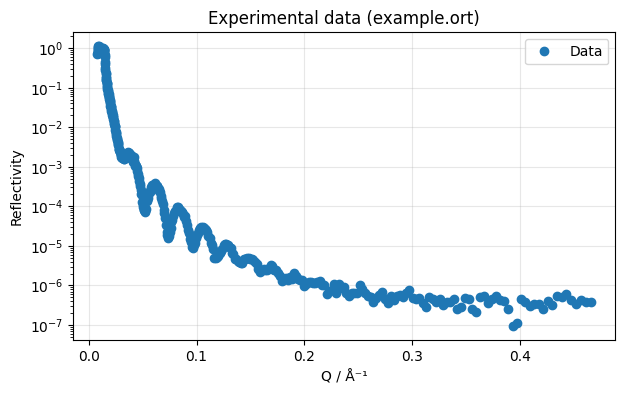

In [2]:
# ---- Load experimental data -------------------------------------------------
# Fetch the .ort test data from the easyscience/reflectometry data repository.
data_path = pooch.retrieve(
    url='https://raw.githubusercontent.com/easyscience/reflectometry/master/data/example.ort',
    known_hash='82d0c95c069092279a799a8131ad3710335f601d9f1080754b387f42e407dfab',
)
data = load(data_path)
print('Data loaded with keys:', list(data.keys()))

# Quick look at the data
qz = data['coords']['Qz_0'].values
r_data = data['data']['R_0'].values

plt.figure(figsize=(7, 4))
plt.semilogy(qz, r_data, 'o', label='Data')
plt.xlabel('Q / Å⁻¹')
plt.ylabel('Reflectivity')
plt.title('Experimental data (example.ort)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# ---- Create a monolayer model (Si / Film / D₂O) ----------------------------
si = Material(sld=2.07, isld=0.0, name='Si')
film = Material(sld=2.0, isld=0.0, name='Film')
d2o = Material(sld=6.36, isld=0.0, name='D2O')

si_layer = Layer(material=si, thickness=0.0, roughness=3.0, name='Si')
film_layer = Layer(material=film, thickness=250.0, roughness=3.0, name='Film')
d2o_layer = Layer(material=d2o, thickness=0.0, roughness=3.0, name='D2O')

sample = Sample(
    Multilayer(si_layer),
    Multilayer(film_layer),
    Multilayer(d2o_layer),
    name='Monolayer Sample',
)

resolution = PercentageFwhm(0.02)
model = Model(
    sample=sample,
    scale=1.0,
    background=1e-6,
    resolution_function=resolution,
    name='Monolayer Model',
)

# ---- Make key parameters free with realistic bounds (essential for MCMC) -----
film_layer.thickness.fixed = False
film_layer.thickness.bounds = (100, 400)

film.sld.fixed = False
film.sld.bounds = (0.5, 4.0)

model.scale.fixed = False
model.scale.bounds = (0.8, 1.2)

model.background.fixed = False
model.background.bounds = (1e-7, 1e-5)

print('Model created with the following free parameters:')
for p in model.get_parameters():
    if not p.fixed:
        print(f'  {p.name}: value={p.value}, bounds={p.bounds}')

Model created with the following free parameters:
  background: value=1e-06, bounds=(1e-07, 1e-05)
  sld: value=2.0, bounds=(0.5, 4.0)
  thickness: value=250.0, bounds=(100, 400)
  scale: value=1.0, bounds=(0.8, 1.2)


In [4]:
# ---- Set up the calculator and fitter ---------------------------------------
interface = CalculatorFactory()
interface.switch('refnx')  # or 'refl1d'
model.interface = interface

fitter = MultiFitter(model)
# Use the BUMPS backend — DREAM sampling is only available through BUMPS.
fitter.switch_minimizer(AvailableMinimizers.Bumps)

print('Fitter ready with minimizer:', fitter.easy_science_multi_fitter.minimizer.name)

CollectionBase is deprecated and will be removed in a future version. Please migrate to ModelBase or EasyList.


Fitter ready with minimizer: Bumps


Classical fit successful: True
Reduced χ² ≈ 73.7860402885366


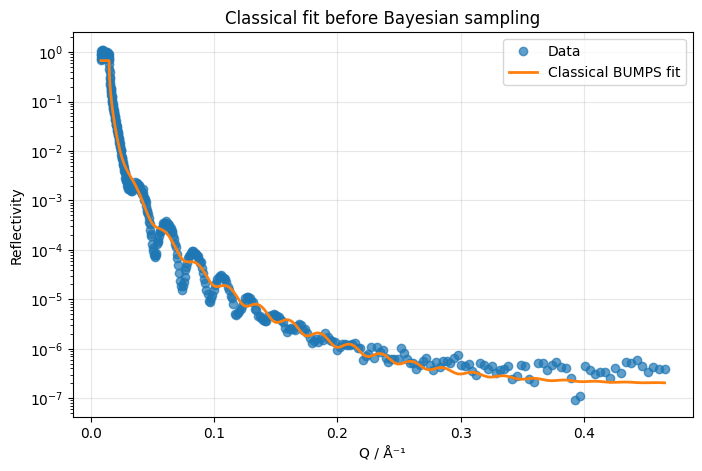

In [5]:
# ---- Classical fit first ----------------------------------------------------
# A classical optimisation gives a good starting point and a sanity check
# before launching the (much more expensive) MCMC sampler.

analysed = fitter.fit(data)

print('Classical fit successful:', analysed.get('success', 'N/A'))
print('Reduced χ² ≈', analysed.get('reduced_chi', 'N/A'))

# Plot the fit
r_model = analysed['R_0_model'].values

plt.figure(figsize=(8, 5))
plt.semilogy(qz, r_data, 'o', label='Data', alpha=0.7)
plt.semilogy(qz, r_model, '-', label='Classical BUMPS fit', linewidth=2)
plt.xlabel('Q / Å⁻¹')
plt.ylabel('Reflectivity')
plt.title('Classical fit before Bayesian sampling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# ---- Bayesian MCMC sampling -------------------------------------------------
# ``MultiFitter.mcmc_sample()`` delegates to the BUMPS DREAM sampler.
# All keyword arguments are forwarded with user-friendly names:
#   ``samples``   ← total retained samples
#   ``burn``      ← burn-in steps
#   ``thin``      ← thinning interval
#   ``population``← BUMPS-native ``pop`` for advanced users
#
# We deliberately start with a *very* short run.  It finishes in seconds but is
# far too short to trust — which is exactly the situation the "extend the chain"
# section below exists to fix.  In production you would ask for 20 k+ samples.

posterior_dict = fitter.mcmc_sample(
    data,
    samples=500,  # Deliberately too short — extended later in this notebook
    burn=100,
    thin=10,
)

print('DREAM sampling complete.')
print(f'  Posterior shape  : {posterior_dict["draws"].shape}')
print(f'  Parameters       : {posterior_dict["param_names"]}')
print()
print(
    'Note: the retained draws are fewer than samples/thin.  BUMPS trims the\n'
    'chain at a detected burn point and drops outlier chains, so the number of\n'
    'rows is not predictable from the arguments — read it off the array.'
)

DREAM sampling complete.
  Posterior shape  : (40, 4)
  Parameters       : ['Layer_1_ThicknessParameter_0', 'Material_1_SldParameter_0', 'Parameter_0', 'Parameter_1']

Note: the retained draws are fewer than samples/thin.  BUMPS trims the
chain at a detected burn point and drops outlier chains, so the number of
rows is not predictable from the arguments — read it off the array.


In [7]:
# ---- Wrap in PosteriorResults -----------------------------------------------
# ``PosteriorResults`` gives you a convenient object with built-in analysis
# methods.  You can also use the raw ``dict`` with the standalone functions
# — both styles are shown below.

posterior = PosteriorResults(
    draws=posterior_dict['draws'],
    param_names=posterior_dict['param_names'],
    logp=posterior_dict.get('logp'),
    sampler_state=posterior_dict.get('state'),
)

print(posterior)

PosteriorResults(n_samples=40, n_params=4, param_names=['Layer_1_ThicknessParameter_0', 'Material_1_SldParameter_0', 'Parameter_0', 'Parameter_1'])


In [8]:
# ---- Posterior summary table ------------------------------------------------
# ``.summary()`` prints mean, standard deviation and 95 % HDI for each parameter.

print(posterior.summary())

parameter                            mean         sd      q2.5%     q97.5%
Layer_1_ThicknessParameter_0     252.6854     0.2168   252.3696   253.1181
Material_1_SldParameter_0          1.5476     0.0092     1.5295     1.5616
Parameter_0                        0.6734     0.0016     0.6699     0.6758
Parameter_1                        0.0000     0.0000     0.0000     0.0000


In [9]:
# ---- Gelman-Rubin R-hat convergence diagnostic ------------------------------
# R-hat compares the variance *between* DREAM's parallel chains with the
# variance *within* each one.  Values close to 1.0 mean the chains have mixed
# and agree on the same posterior; the usual rule of thumb is R̂ < 1.1.
#
# ``posterior.gelman_rubin()`` needs draws pre-split into chains, shape
# ``(n_chains, n_draws, n_params)``.  ``mcmc_sample()`` returns the draws
# already pooled into a flat ``(n_samples, n_params)`` array, so we ask the
# BUMPS state itself — it still knows the individual chains.


def rhat_table(state, param_names):
    """R-hat per parameter, read from the chain-aware BUMPS state."""
    return dict(zip(param_names, state.gelman()))


rhat_short = rhat_table(posterior.sampler_state, posterior.param_names)

print('Gelman-Rubin R-hat after the short run:')
for name, r in rhat_short.items():
    flag = ' ✓' if r < 1.1 else ' ⚠ not converged'
    print(f'  {name:<30s}  R̂ = {r:.3f}{flag}')

# DREAM is stochastic and unseeded, so the exact values differ run to run.
n_bad = sum(r >= 1.1 for r in rhat_short.values())
if n_bad:
    print(f'\n{n_bad} parameter(s) above 1.1 — this chain is not converged and needs more samples.')
else:
    print(
        f'\nR̂ passes, but this chain holds only {posterior.draws.shape[0]} draws — '
        'far too few to rely on,\nso every posterior estimate from it is coarse. '
        'Either way, the answer is more samples.'
    )

Gelman-Rubin R-hat after the short run:
  Layer_1_ThicknessParameter_0    R̂ = 1.184 ⚠ not converged
  Material_1_SldParameter_0       R̂ = 1.300 ⚠ not converged
  Parameter_0                     R̂ = 0.902 ✓
  Parameter_1                     R̂ = 1.190 ⚠ not converged

3 parameter(s) above 1.1 — this chain is not converged and needs more samples.


## Extending the chain

The short run above is not something to draw conclusions from — it usually
fails the R̂ < 1.1 check outright, and even when it scrapes past it, it holds
only a few dozen draws. The fix is more samples, but restarting from scratch
would throw away the work already done and pay the burn-in cost a second time.

Instead, **continue the existing chain**. `MultiFitter.mcmc_sample()` keeps the
underlying `Sampler` on `fitter.sampler`, and `Sampler.extend()` picks the chain
up exactly where DREAM left off:

```python
extended = fitter.sampler.extend(additional_samples=8000, thin=10)
```

`extend()` runs with `burn=0` — re-burning an already-converged chain would be a
mistake, and BUMPS forces it to 0 on resume anyway. It also grows DREAM's
fixed-size ring buffer by exactly `additional_samples`, so none of the existing
draws are evicted.

### What "improvement" does and does not mean here

Two things get better, and one thing deliberately does not:

* **R̂ drops** — the chains mix and settle onto the same posterior.
* **The Monte-Carlo error shrinks** — with more draws the posterior *estimate*
  (mean, credible interval, histogram shape) stops moving from run to run.
* **The posterior width does _not_ shrink.** The spread of a parameter is set by
  the data and the model, not by how long you sample. If the credible interval
  collapsed as we added samples, that would be a bug, not a win. What improves is
  how precisely we know that interval.

DREAM is stochastic and this notebook does not seed it, so the exact numbers
below change on every run. The direction of travel does not.

In [10]:
# ---- Continue the existing chain --------------------------------------------
# ``extend()`` mutates the sampler's BUMPS state in place, so snapshot anything
# we want to compare against first.  ``rhat_short`` (plain floats) was already
# captured above; the draws need an explicit copy.

draws_short = np.array(posterior.draws, copy=True)
n_short = draws_short.shape[0]

extended_results = fitter.sampler.extend(
    additional_samples=8000,  # Added on top of the original 2000
    thin=10,
)

posterior_extended = PosteriorResults(
    draws=extended_results.draws,
    param_names=extended_results.param_names,
    logp=extended_results.logp,
    sampler_state=extended_results.state,
)

print('Chain extended.')
print(f'  Retained draws before : {n_short}')
print(f'  Retained draws after  : {posterior_extended.draws.shape[0]}')

Chain extended.
  Retained draws before : 40
  Retained draws after  : 880


In [11]:
# ---- Did convergence actually improve? --------------------------------------
# The headline check: R-hat before vs after.

rhat_extended = rhat_table(posterior_extended.sampler_state, posterior_extended.param_names)

print(f'{"parameter":<32s} {"short":>8s} {"extended":>10s}')
print('-' * 54)
for name in posterior_extended.param_names:
    before, after = rhat_short[name], rhat_extended[name]
    flag = ' ✓' if after < 1.1 else ' ⚠'
    print(f'{name:<32s} {before:8.3f} {after:10.3f}{flag}')

n_bad_before = sum(r >= 1.1 for r in rhat_short.values())
n_bad_after = sum(r >= 1.1 for r in rhat_extended.values())
print(f'\nParameters failing R̂ < 1.1:  {n_bad_before} → {n_bad_after}')
print(f'Worst R̂ across parameters:   {max(rhat_short.values()):.3f} → {max(rhat_extended.values()):.3f}')

if n_bad_after == 0 and n_bad_before > 0:
    print('\nThe extended chain has converged; the short one had not.')
elif n_bad_after == 0:
    print('\nBoth chains pass R̂, but the extended one does so with far more draws behind it.')
else:
    print('\nStill above threshold — extend again, or revisit the model and its bounds.')

parameter                           short   extended
------------------------------------------------------
Layer_1_ThicknessParameter_0        1.184      1.033 ✓
Material_1_SldParameter_0           1.300      1.032 ✓
Parameter_0                         0.902      1.015 ✓
Parameter_1                         1.190      1.014 ✓

Parameters failing R̂ < 1.1:  3 → 0
Worst R̂ across parameters:   1.300 → 1.033

The extended chain has converged; the short one had not.


In [12]:
# ---- Side-by-side posterior statistics --------------------------------------
# ``extend()`` returns the parameters in the same order as the original run, so
# the columns line up — but map by name rather than trusting the index.

col_short = {name: i for i, name in enumerate(posterior.param_names)}
col_ext = {name: i for i, name in enumerate(posterior_extended.param_names)}


def ci_width(column, alpha=0.95):
    lo, hi = np.percentile(column, [100 * (1 - alpha) / 2, 100 * (1 + alpha) / 2])
    return hi - lo


header = (
    f'{"parameter":<32s} {"mean (short)":>13s} {"mean (ext)":>13s} {"shift":>8s} {"95% w (short)":>14s} {"95% w (ext)":>13s}'
)
print(header)
print('-' * len(header))

for name in posterior_extended.param_names:
    a = draws_short[:, col_short[name]]
    b = posterior_extended.draws[:, col_ext[name]]
    # Mean shift expressed in extended-posterior standard deviations: how far the
    # short run's answer sits from the better-resolved one, in units that matter.
    shift = abs(np.mean(a) - np.mean(b)) / np.std(b)
    print(f'{name:<32s} {np.mean(a):13.5g} {np.mean(b):13.5g} {shift:7.2f}σ {ci_width(a):14.4g} {ci_width(b):13.4g}')

print(
    '\nRead this alongside the R̂ table, not on its own.  The credible intervals do\n'
    'not systematically shrink — they should not, since posterior width is set by\n'
    'the data, not by sampling effort.  What extending buys is trust: the means\n'
    'stop drifting and the marginals below are resolved by many more draws.'
)

parameter                         mean (short)    mean (ext)    shift  95% w (short)   95% w (ext)
--------------------------------------------------------------------------------------------------
Layer_1_ThicknessParameter_0            252.69        252.65    0.19σ         0.7485        0.7588
Material_1_SldParameter_0               1.5476        1.5478    0.03σ        0.03217       0.03278
Parameter_0                             0.6734       0.67347    0.03σ       0.005931      0.007952
Parameter_1                         1.9756e-07     1.969e-07    0.04σ       6.24e-08     5.631e-08

Read this alongside the R̂ table, not on its own.  The credible intervals do
not systematically shrink — they should not, since posterior width is set by
the data, not by sampling effort.  What extending buys is trust: the means
stop drifting and the marginals below are resolved by many more draws.


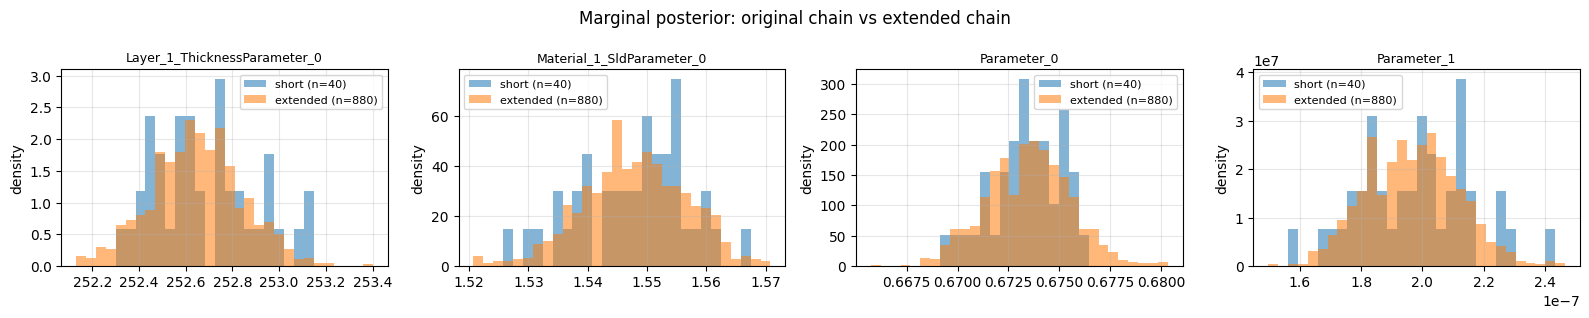

In [13]:
# ---- Visual overlay: marginals, short vs extended ----------------------------
# Same posterior, better resolved.  The short run's histogram is ragged because
# it is built from few draws; the extended one traces a smooth marginal over the
# same range.  Densities are normalised so the two are comparable despite the
# very different sample counts.

n_params = len(posterior_extended.param_names)
fig, axes = plt.subplots(1, n_params, figsize=(4 * n_params, 3.2))
axes = np.atleast_1d(axes)

for ax, name in zip(axes, posterior_extended.param_names):
    a = draws_short[:, col_short[name]]
    b = posterior_extended.draws[:, col_ext[name]]
    bins = np.histogram_bin_edges(np.concatenate([a, b]), bins=30)
    ax.hist(a, bins=bins, density=True, alpha=0.55, label=f'short (n={a.shape[0]})')
    ax.hist(b, bins=bins, density=True, alpha=0.55, label=f'extended (n={b.shape[0]})')
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Marginal posterior: original chain vs extended chain')
fig.tight_layout()
plt.show()

In [14]:
# ---- Adopt the extended chain for the rest of the notebook -------------------
# Everything below (corner plots, credible intervals, posterior-predictive
# checks) now runs on the converged chain.  ``posterior_short`` is kept around
# in case you want to re-run the comparisons above.

posterior_short = posterior
posterior = posterior_extended

print(posterior)
print()
print(posterior.summary())

PosteriorResults(n_samples=880, n_params=4, param_names=['Layer_1_ThicknessParameter_0', 'Material_1_SldParameter_0', 'Parameter_0', 'Parameter_1'])

parameter                            mean         sd      q2.5%     q97.5%
Layer_1_ThicknessParameter_0     252.6491     0.1950   252.2677   253.0265
Material_1_SldParameter_0          1.5478     0.0088     1.5307     1.5635
Parameter_0                        0.6735     0.0021     0.6695     0.6775
Parameter_1                        0.0000     0.0000     0.0000     0.0000


## Interactive posterior plots

The next three cells render the same Plotly figures that are shown on the
Bayesian Posterior tab of the EasyReflectometryApp:

* **Marginals** — per-parameter distribution: histogram + smooth KDE marginal,
  shaded 95% credible interval, and median / best-sample lines
  (`plot_distribution` or `posterior.distribution()`)
* **Corner plot** — pairwise marginals + 2-D contours + scatter (`plot_corner`)
* **Traces** — per-chain trace + marginal histogram (`plot_trace`)

The standalone helpers are called with ``return_figure=True`` so they return a
Plotly ``Figure`` that we render in the notebook with ``fig.show()``; the
``PosteriorResults`` methods return the figure directly.

In [15]:
# ---- Marginal posterior distributions ---------------------------------------
# One panel per free parameter, each overlaying the posterior histogram, a
# smooth Gaussian-KDE marginal, the shaded 95% credible interval, and the
# median / best-sample reference lines.  Mirrors the "Marginals" sub-tab in
# the EasyReflectometryApp.

# The PosteriorResults method passes ``logp`` through automatically so the
# best posterior sample (MAP) line is drawn:
fig = posterior.distribution()
fig.show()

# Standalone equivalent (pass ``logp`` to get the best-sample line):
# fig = plot_distribution(
#     posterior.draws,
#     posterior.param_names,
#     logp=posterior.logp,
#     return_figure=True,
# )
# fig.show()

In [16]:
# ---- Corner plot ------------------------------------------------------------
# Pairwise correlations: marginal density on the diagonal, scatter samples
# and 2-D contours on the lower triangle.  Mirrors the "Corner Plot" sub-tab.

fig = plot_corner(posterior.draws, posterior.param_names)
fig.show()

In [17]:
# ---- Trace plot -------------------------------------------------------------
# Per-chain trace (left column) and marginal histogram (right column).
# Mirrors the "Traces" sub-tab in the EasyReflectometryApp.

fig = plot_trace(posterior.draws, posterior.param_names, return_figure=True)
fig.show()

In [18]:
# ---- Credible intervals -----------------------------------------------------
# Equal-tailed 95 % credible intervals for each parameter.

ci_95 = posterior.credible_interval(alpha=0.95)
print('95 % credible intervals:')
for name, (lo, hi) in ci_95.items():
    print(f'  {name:<30s}  [{lo:.4f}, {hi:.4f}]')

# You can request narrower intervals too:
ci_50 = posterior.credible_interval(alpha=0.50)
print('\n50 % credible intervals:')
for name, (lo, hi) in ci_50.items():
    print(f'  {name:<30s}  [{lo:.4f}, {hi:.4f}]')

# Standalone equivalent:
# ci = credible_intervals(posterior.draws, posterior.param_names, alpha=0.95)

95 % credible intervals:
  Layer_1_ThicknessParameter_0    [252.2677, 253.0265]
  Material_1_SldParameter_0       [1.5307, 1.5635]
  Parameter_0                     [0.6695, 0.6775]
  Parameter_1                     [0.0000, 0.0000]

50 % credible intervals:
  Layer_1_ThicknessParameter_0    [252.5202, 252.7693]
  Material_1_SldParameter_0       [1.5421, 1.5541]
  Parameter_0                     [0.6720, 0.6748]
  Parameter_1                     [0.0000, 0.0000]


In [19]:
# ---- Pairwise focus: thickness vs SLD ---------------------------------------
# A 2-parameter corner plot zooms in on the joint posterior for a specific
# pair.  This is the same view the EasyReflectometryApp's "2D Heatmap"
# sub-tab uses to inspect parameter degeneracies.


params_of_interest = ['Layer_1_ThicknessParameter_0', 'Material_1_SldParameter_0']
idx = [posterior.param_names.index(p) for p in params_of_interest]
subset_draws = np.asarray(posterior.draws)[:, idx]

fig = plot_corner(subset_draws, params_of_interest)
fig.show()

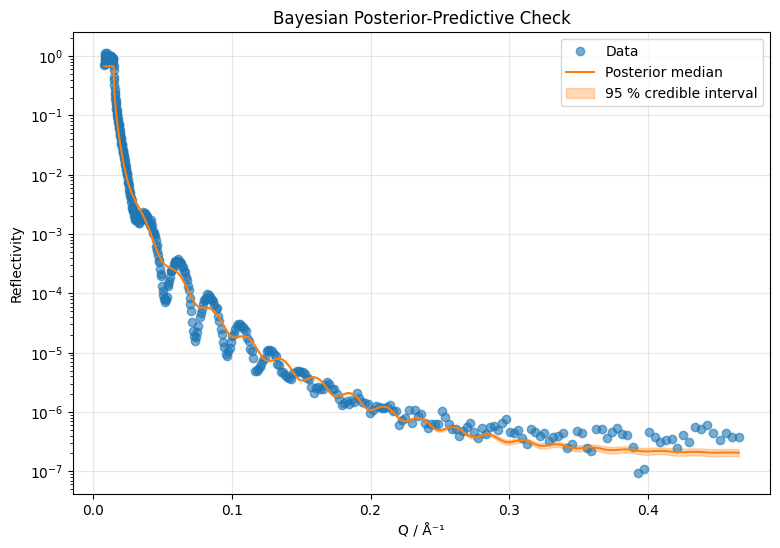

The 95 % credible interval captures parameter uncertainty propagated through the model.


In [20]:
# ---- Posterior-predictive reflectivity --------------------------------------
# Propagate parameter uncertainty through the model to obtain median
# reflectivity and 95 % credible band.

r_median, r_lower, r_upper = posterior_predictive_reflectivity(
    posterior.draws,
    posterior.param_names,
    model,
    qz,
    n_samples=200,
)

plt.figure(figsize=(9, 6))
plt.semilogy(qz, r_data, 'o', label='Data', alpha=0.6)
plt.semilogy(qz, r_median, '-', color='tab:orange', label='Posterior median')
plt.fill_between(
    qz,
    r_lower,
    r_upper,
    color='tab:orange',
    alpha=0.3,
    label='95 % credible interval',
)
plt.xlabel('Q / Å⁻¹')
plt.ylabel('Reflectivity')
plt.title('Bayesian Posterior-Predictive Check')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('The 95 % credible interval captures parameter uncertainty propagated through the model.')

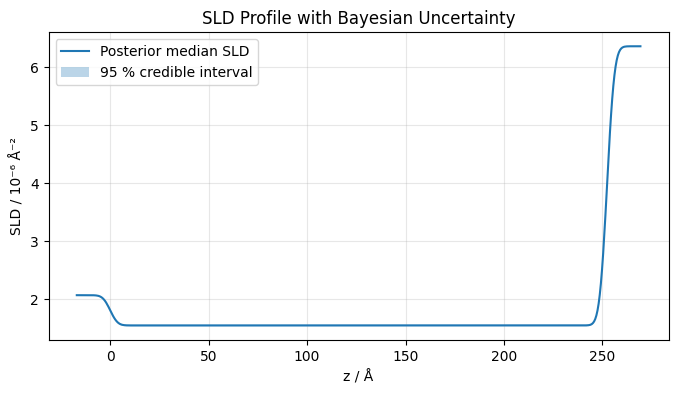

In [21]:
# ---- Posterior-predictive SLD profile ---------------------------------------
# The same idea applied to the scattering-length-density profile.

z, sld_median, sld_lower, sld_upper = posterior_predictive_sld_profile(
    posterior.draws,
    posterior.param_names,
    model,
    n_samples=200,
)

plt.figure(figsize=(8, 4))
plt.plot(z, sld_median, label='Posterior median SLD')
plt.fill_between(
    z,
    sld_lower,
    sld_upper,
    alpha=0.3,
    label='95 % credible interval',
)
plt.xlabel('z / Å')
plt.ylabel('SLD / 10⁻⁶ Å⁻²')
plt.title('SLD Profile with Bayesian Uncertainty')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# ---- Summary ----------------------------------------------------------------
print('―' * 60)
print('Bayesian analysis complete!')
print('―' * 60)
print()
print('API surface demonstrated:')
print('  MultiFitter.mcmc_sample(data, samples=, burn=, thin=)')
print('  MultiFitter.sampler            — the Sampler behind the last run')
print('    .extend(additional_samples=, thin=)')
print('                                — continue the chain, no re-burn')
print('    .state.gelman()             — chain-aware R̂ (works on pooled draws)')
print('  PosteriorResults(draws, param_names, logp=, sampler_state=)')
print('    .summary()                — formatted parameter table')
print('    .distribution()           — per-parameter marginal Plotly figure')
print('    .corner()                 — pairwise correlation Plotly figure')
print('    .trace()                  — MCMC chain trace plot')
print('    .credible_interval(alpha) — equal-tailed credible intervals')
print('    .gelman_rubin()           — R̂ for draws pre-split into chains')
print()
print('  Standalone functions (work on raw dict; the plot helpers return')
print('  the same interactive Plotly figures as the App):')
print('    posterior_summary(draws, names)')
print('    plot_distribution(draws, names, logp=, return_figure=True)')
print('    plot_corner(draws, names)')
print('    plot_trace(draws, names, return_figure=True)')
print('    credible_intervals(draws, names, alpha)')
print('    posterior_predictive_reflectivity(draws, names, model, q, n)')
print('    posterior_predictive_sld_profile(draws, names, model, n)')
print()
print('Workflow: fit → sample short → check R̂ → extend until converged → analyse.')
print('Extending continues the existing chain, so the burn-in is paid only once.')

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Bayesian analysis complete!
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

API surface demonstrated:
  MultiFitter.mcmc_sample(data, samples=, burn=, thin=)
  MultiFitter.sampler            — the Sampler behind the last run
    .extend(additional_samples=, thin=)
                                — continue the chain, no re-burn
    .state.gelman()             — chain-aware R̂ (works on pooled draws)
  PosteriorResults(draws, param_names, logp=, sampler_state=)
    .summary()                — formatted parameter table
    .distribution()           — per-parameter marginal Plotly figure
    .corner()                 — pairwise correlation Plotly figure
    .trace()                  — MCMC chain trace plot
    .credible_interval(alpha) — equal-tailed credible intervals
    .gelman_rubin()           — R̂ for draws pre-split into chains

  Standalone functions (work on raw dict; the plot helpers return
  the same int